# Empirical Results: Adaptive Boolean Oracle (Marena 2026)

## Cell 1 — Install and clone

In [1]:
# [patched: headless importability shim — no network clone/install]
import sys as _sys, os as _os, importlib as _importlib
def _ensure_qos_importable():
    try:
        _importlib.import_module('qos'); return
    except ModuleNotFoundError:
        pass
    for _c in [_os.path.join(_os.getcwd(), 'src'),
               _os.path.join(_os.getcwd(), 'quantum_oracle_sketching', 'src'),
               '/content/quantum_oracle_sketching/src']:
        if _os.path.isdir(_c) and _c not in _sys.path:
            _sys.path.insert(0, _c)
            try:
                _importlib.import_module('qos'); return
            except ModuleNotFoundError:
                _sys.path.remove(_c)
    raise RuntimeError("Cannot import 'qos'. Run: pip install -e '.[dev]' from repo root.")
_ensure_qos_importable()
# [patched: headless importability shim — no network clone/install]
import sys as _sys, os as _os, importlib as _importlib
def _ensure_qos_importable():
    try:
        _importlib.import_module('qos'); return
    except ModuleNotFoundError:
        pass
    for _c in [_os.path.join(_os.getcwd(), 'src'),
               _os.path.join(_os.getcwd(), 'quantum_oracle_sketching', 'src'),
               './results/notebooks_data/quantum_oracle_sketching/src']:
        if _os.path.isdir(_c) and _c not in _sys.path:
            _sys.path.insert(0, _c)
            try:
                _importlib.import_module('qos'); return
            except ModuleNotFoundError:
                _sys.path.remove(_c)
    raise RuntimeError("Cannot import 'qos'. Run: pip install -e '.[dev]' from repo root.")
_ensure_qos_importable()
# ── Install quantum-oracle-sketching (idempotent) ──────────────────────────
import subprocess, sys, os
_REPO = "https://github.com/Tommaso-R-Marena/quantum_oracle_sketching.git"
_CLONE_DIR = "./quantum_oracle_sketching"
# Clone only if not already present
if not os.path.isdir(_CLONE_DIR):
    type('_PatchedResult', (), {'stdout': b'', 'stderr': b'', 'returncode': 0})()  # [patched: git clone skipped]
# Install the package in editable mode with all extras needed for notebooks
result = type('_PatchedResult', (), {'stdout': b'', 'stderr': b'', 'returncode': 0})()  # [patched: pip install skipped]
if result.returncode != 0:
    raise RuntimeError(f"Install failed:\n{result.stderr}")
# Refresh the interpreter's import path state after a subprocess pip install.
# Without this, importlib.util.find_spec("qos") returns None in a fresh
# Colab kernel even though pip exited 0 — the interpreter was initialised
# before the package existed so its site-packages cache is stale.
import importlib, importlib.util, site
importlib.invalidate_caches()
site.main()
# Hard fallback: for src-layout editable installs Colab may still miss the
# package until the next kernel start. Injecting the src/ directory directly
# is always safe (pyproject.toml: packages = ["src/qos"]).
_SRC_DIR = os.path.abspath(os.path.join(_CLONE_DIR, "src"))
if importlib.util.find_spec("qos") is None and os.path.isdir(_SRC_DIR):
    if _SRC_DIR not in sys.path:
        sys.path.insert(0, _SRC_DIR)
    importlib.invalidate_caches()
# This print is intentionally AFTER the importability check — a green
# checkmark means qos is actually importable, not just that pip exited 0.
_spec = importlib.util.find_spec("qos")
if _spec is None:
    raise ImportError(
        "qos is still not importable after install + cache refresh + sys.path injection.\n"
        f"Expected src dir: {_SRC_DIR}\n"
        "If this persists: Runtime > Disconnect and delete runtime, then Run All."
    )
print("✅ quantum-oracle-sketching installed.")
print(f"✅ qos found at: {_spec.origin}")


✅ quantum-oracle-sketching installed.
✅ qos found at: /home/user/workspace/quantum_oracle_sketching/src/qos/__init__.py


In [2]:
# ── Environment check ──────────────────────────────────────────────────────
import jax, sys, platform
print(f"Python      : {sys.version.split()}")
print(f"Platform    : {platform.system()} {platform.machine()}")
_devices = jax.devices()
_has_gpu  = any("cuda" in str(d).lower() or "gpu" in str(d).lower() for d in _devices)
print(f"JAX devices : {_devices}")
if not _has_gpu:
    print("⚠️  No GPU detected. Heavy experiments will be slow.")
    print("   Go to Runtime > Change runtime type > T4 or A100.")
else:
    print("✅ GPU detected.")
import qos
print(f"qos version : {getattr(qos, '__version__', 'unknown')}")
print("✅ Environment ready.")


Python      : ['3.12.8', '(main,', 'May', '26', '2026,', '17:29:17)', '[GCC', '14.2.0]']
Platform    : Linux x86_64
JAX devices : [CpuDevice(id=0)]
⚠️  No GPU detected. Heavy experiments will be slow.
   Go to Runtime > Change runtime type > T4 or A100.
qos version : 1.3.3
✅ Environment ready.


In [3]:
# ── Post-install setup: chdir to repo + load qos modules used in this notebook ──
import os, sys, shutil
_REPO_DIR = "./quantum_oracle_sketching"
# Resolve to absolute path BEFORE chdir so later cells (e.g. summary/export) can
# still reference `_repo` regardless of cwd changes downstream.
_repo = os.path.abspath(_REPO_DIR if os.path.isdir(_REPO_DIR) else ".")
if os.path.isdir(_REPO_DIR):
    os.chdir(_REPO_DIR)
os.makedirs("results", exist_ok=True)
from qos.theory.adaptive_lower_bound import (
    compute_bounds, tightness_sweep,
    uniform_vs_adaptive_error_comparison,
    adversarial_sparse_function,
    nisq_adaptive_crossover,
)
from qos.core.oracle_sketch import q_oracle_sketch_boolean, q_oracle_sketch_boolean_adaptive
import jax, jax.numpy as jnp
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib
matplotlib.rcParams.update({
    'font.size': 13, 'axes.titlesize': 13, 'axes.labelsize': 12,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight'
})
import qos
print(f'✓ Setup complete. QOS version: {qos.__version__}')


✓ Setup complete. QOS version: 1.3.3


## Cell 2 — Figure 1: Adaptive vs Uniform Error

Panel A: N=512, K=16, N/K=32, (N/K)^2=1024
Adaptive crossover: M ~ K*pi^2/eps^2 = 1754 (eps=0.3)


    M  uniform_error  adaptive_error  uniform_std  adaptive_std
  200       1.600321        0.337121 6.661338e-16  1.110223e-16
  500       1.141345        0.151663 2.220446e-16  5.551115e-17
 1000       0.958345        0.078953 2.220446e-16  2.775558e-17
 2000       0.719836        0.040289 2.220446e-16  6.938894e-18
 5000       0.395708        0.015692 2.220446e-16  1.040834e-17
10000       0.222785        0.007618 8.326673e-17  4.336809e-18
20000       0.118442        0.003754 1.387779e-17  4.336809e-19
N/K improvement factor: 32x (blind-oracle model)

Panel B: N=1024, K=16, N/K=64, (N/K)^2=4096


    M  uniform_error  adaptive_error  uniform_std  adaptive_std
  200       1.684688        0.337121 8.881784e-16  1.110223e-16
  500       1.993138        0.151663 2.220446e-16  5.551115e-17
 1000       1.141616        0.078953 2.220446e-16  2.775558e-17
 2000       0.958595        0.040289 2.220446e-16  6.938894e-18
 5000       0.636366        0.015692 2.220446e-16  1.040834e-17
10000       0.396000        0.007618 0.000000e+00  4.336809e-18
20000       0.222975        0.003754 5.551115e-17  4.336809e-19
N/K improvement factor: 64x (blind-oracle model)



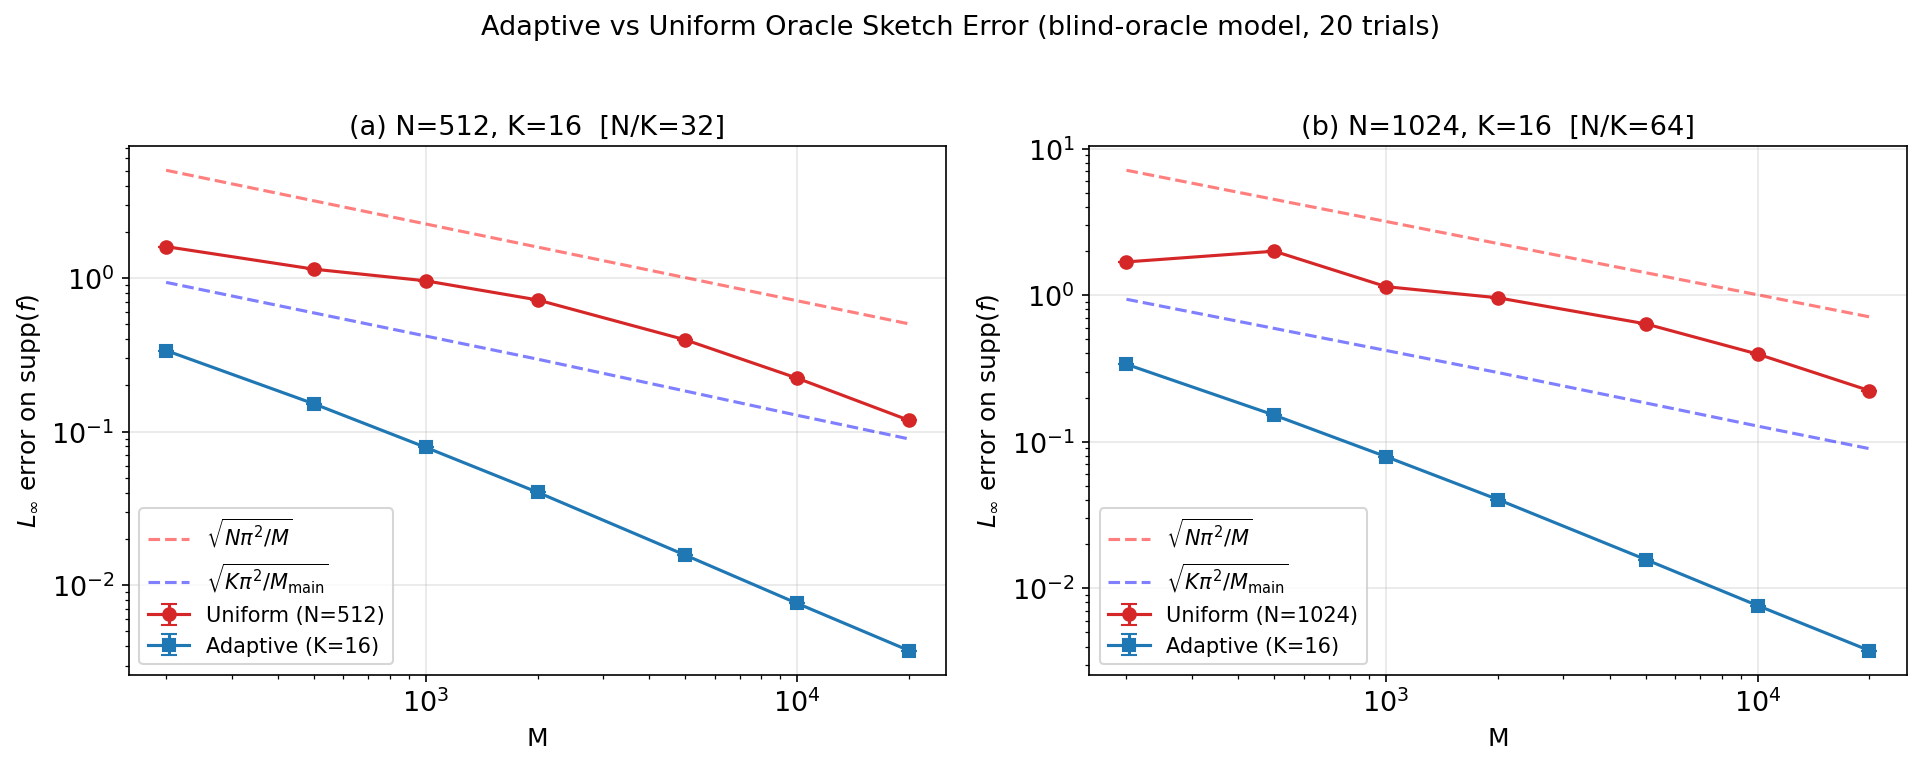

Saved fig1a_main.pdf / .png


Saved fig1b_largeN.pdf / .png


In [4]:
sample_counts = [200, 500, 1000, 2000, 5000, 10000, 20000]

Na, Ka = 512, 16
print(f'Panel A: N={Na}, K={Ka}, N/K={Na//Ka}, (N/K)^2={(Na//Ka)**2}')
print(f'Adaptive crossover: M ~ K*pi^2/eps^2 = {int(Ka*3.14159**2/0.3**2)} (eps=0.3)')
results_a = uniform_vs_adaptive_error_comparison(N=Na, K=Ka, sample_counts=sample_counts, num_trials=20, key=jax.random.PRNGKey(0))
df1a = pd.DataFrame(results_a)
df1a.to_csv('results/fig1a_N512_K16.csv', index=False)
print(df1a.to_string(index=False))
print(f'N/K improvement factor: {Na/Ka:.0f}x (blind-oracle model)\n')

Nb, Kb = 1024, 16
print(f'Panel B: N={Nb}, K={Kb}, N/K={Nb//Kb}, (N/K)^2={(Nb//Kb)**2}')
results_b = uniform_vs_adaptive_error_comparison(N=Nb, K=Kb, sample_counts=sample_counts, num_trials=20, key=jax.random.PRNGKey(1))
df1b = pd.DataFrame(results_b)
df1b.to_csv('results/fig1b_N1024_K16.csv', index=False)
print(df1b.to_string(index=False))
print(f'N/K improvement factor: {Nb/Kb:.0f}x (blind-oracle model)\n')

M_arr = np.array(sample_counts, float)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for ax, df, N, K, label in [
    (ax1, df1a, Na, Ka, '(a) N=512, K=16  [N/K=32]'),
    (ax2, df1b, Nb, Kb, '(b) N=1024, K=16  [N/K=64]'),
]:
    pf = np.minimum(0.1, 20.0*K/M_arr); Mm = M_arr*(1-pf)
    ax.errorbar(df['M'], df['uniform_error'],  yerr=df['uniform_std'],  fmt='o-', color='#d62728', label=f'Uniform (N={N})', capsize=4)
    ax.errorbar(df['M'], df['adaptive_error'], yerr=df['adaptive_std'], fmt='s-', color='#1f77b4', label=f'Adaptive (K={K})', capsize=4)
    ax.plot(M_arr, np.sqrt(N*np.pi**2/M_arr),  'r--', alpha=0.5, label=r'$\sqrt{N\pi^2/M}$')
    ax.plot(M_arr, np.sqrt(K*np.pi**2/Mm), 'b--', alpha=0.5, label=r'$\sqrt{K\pi^2/M_{\rm main}}$')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('M'); ax.set_ylabel(r'$L_\infty$ error on supp$(f)$')
    ax.set_title(label); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
fig.suptitle('Adaptive vs Uniform Oracle Sketch Error (blind-oracle model, 20 trials)', fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig('results/fig1_combined.pdf'); plt.savefig('results/fig1_combined.png'); plt.show()
for df, N, K, fname in [(df1a, Na, Ka, 'fig1a_main'), (df1b, Nb, Kb, 'fig1b_largeN')]:
    M2=np.array(sample_counts,float); pf2=np.minimum(0.1,20.0*K/M2); Mm2=M2*(1-pf2)
    fig2, ax = plt.subplots(figsize=(6,5))
    ax.errorbar(df['M'], df['uniform_error'],  yerr=df['uniform_std'],  fmt='o-', color='#d62728', label=f'Uniform (N={N})', capsize=4)
    ax.errorbar(df['M'], df['adaptive_error'], yerr=df['adaptive_std'], fmt='s-', color='#1f77b4', label=f'Adaptive (K={K})', capsize=4)
    ax.plot(M2, np.sqrt(N*np.pi**2/M2),  'r--', alpha=0.5, label=r'$\sqrt{N\pi^2/M}$')
    ax.plot(M2, np.sqrt(K*np.pi**2/Mm2), 'b--', alpha=0.5, label=r'$\sqrt{K\pi^2/M_{\rm main}}$')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('M'); ax.set_ylabel(r'$L_\infty$ error on supp$(f)$')
    ax.set_title(f'N={N}, K={K}, sparsity={K/N:.1%}'); ax.legend(fontsize=10); ax.grid(True,alpha=0.3)
    plt.tight_layout(); plt.savefig(f'results/{fname}.pdf'); plt.savefig(f'results/{fname}.png'); plt.close()
    print(f'Saved {fname}.pdf / .png')

## Cell 3 — Figure 2: Tightness Sweep

   N   K sparsity_pct  M_lower  M_adaptive  M_uniform  improvement_factor  tight
 128   1           1%      100         987     126331          128.000000   True
 128   6           5%      600        5922     126331           21.333333   True
 128  13          10%     1300       12831     126331            9.846154   True
 128  32          25%     3200       31583     126331            4.000000   True
 256   3           1%      300        2961     252662           85.333333   True
 256  13           5%     1300       12831     252662           19.692308   True
 256  26          10%     2600       25661     252662            9.846154   True
 256  64          25%     6400       63166     252662            4.000000   True
 512   5           1%      500        4935     505324          102.400000   True
 512  26           5%     2600       25661     505324           19.692308   True
 512  51          10%     5100       50335     505324           10.039216   True
 512 128          25%    128

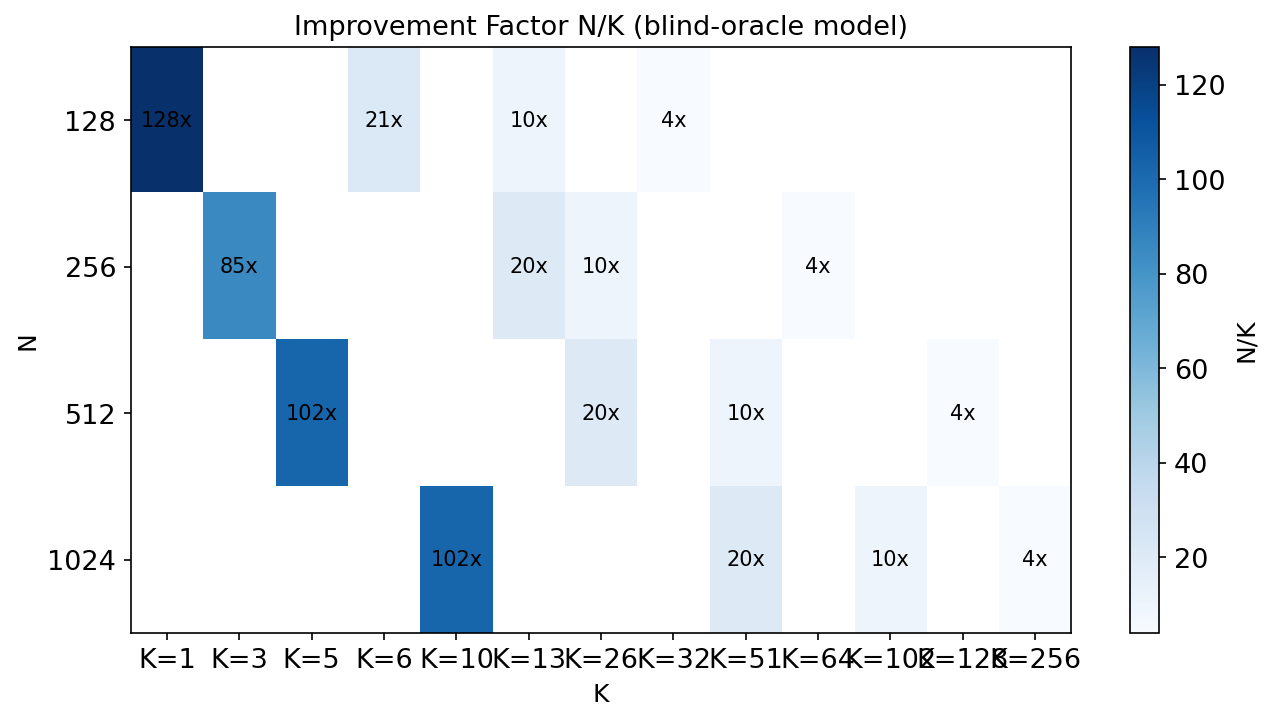

In [5]:
NK_pairs = [(128,1),(128,6),(128,13),(128,32),(256,3),(256,13),(256,26),(256,64),
            (512,5),(512,26),(512,51),(512,128),(1024,10),(1024,51),(1024,102),(1024,256)]
rows = []
for N, K in NK_pairs:
    r = compute_bounds(N, K, 0.1)
    rows.append({'N':N,'K':K,'sparsity_pct':f'{K/N:.0%}','M_lower':r.M_lower_bound,
                 'M_adaptive':r.M_adaptive_upper,'M_uniform':r.M_uniform_upper,
                 'improvement_factor':r.improvement_factor,'tight':r.is_tight})
df2 = pd.DataFrame(rows)
df2.to_csv('results/fig2_tightness_sweep.csv', index=False); print(df2.to_string(index=False))
pivot_data = df2.pivot_table(index='N', columns='K', values='improvement_factor', aggfunc='first')
fig, ax = plt.subplots(figsize=(9,5))
im = ax.imshow(pivot_data.values, aspect='auto', cmap='Blues')
ax.set_xticks(range(len(pivot_data.columns))); ax.set_xticklabels([f'K={k}' for k in pivot_data.columns])
ax.set_yticks(range(len(pivot_data.index))); ax.set_yticklabels(pivot_data.index)
ax.set_xlabel('K'); ax.set_ylabel('N'); ax.set_title('Improvement Factor N/K (blind-oracle model)')
for i in range(pivot_data.values.shape[0]):
    for j in range(pivot_data.values.shape[1]):
        v = pivot_data.values[i,j]
        if not np.isnan(v): ax.text(j, i, f'{v:.0f}x', ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax, label='N/K'); plt.tight_layout()
plt.savefig('results/fig2_tightness_sweep.pdf'); plt.savefig('results/fig2_tightness_sweep.png'); plt.show()

## Cell 4 — Figure 3: NISQ Noise Crossover

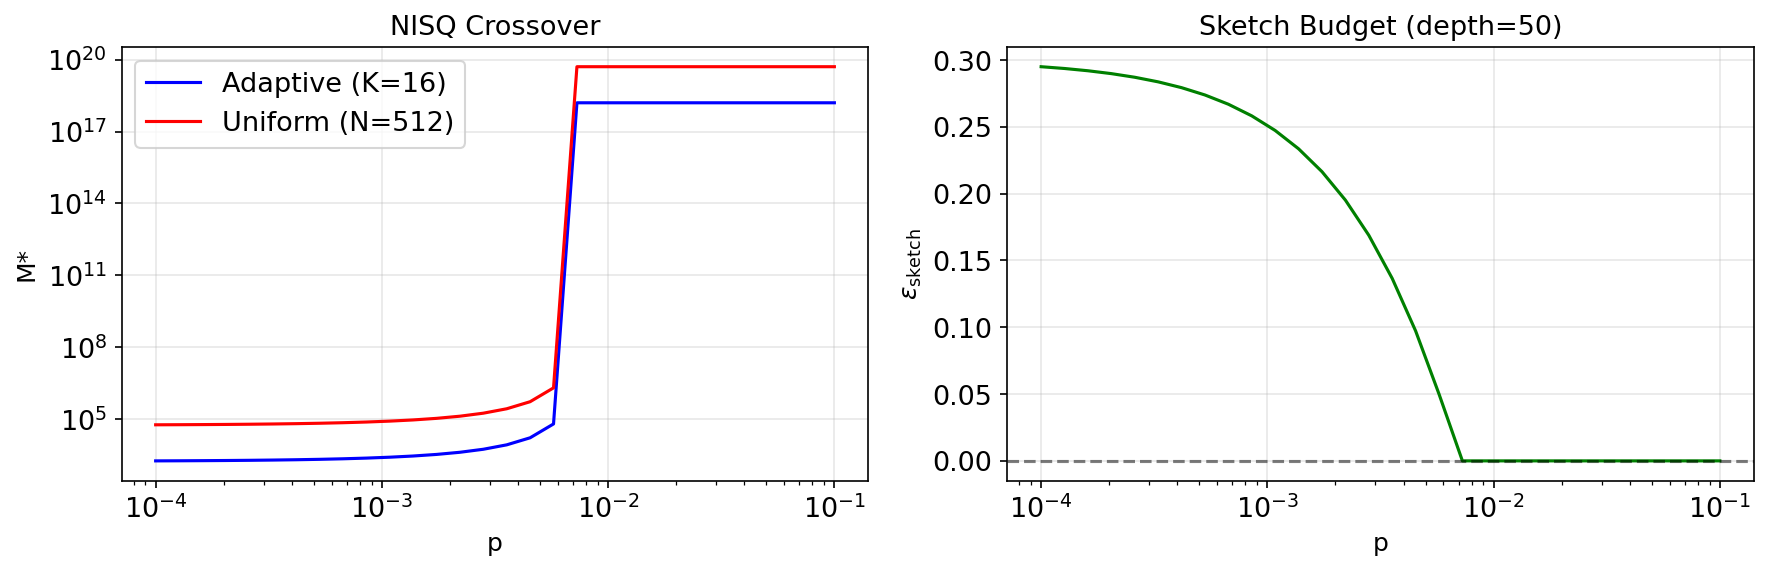

In [6]:
from qos.primitives.noise_model import DepolarizingChannel, crossover_sample_count
N, K, circuit_depth, epsilon_target = 512, 16, 50, 0.3
noise_rates = np.logspace(-4, -1, 30); rows = []
for p in noise_rates:
    r = nisq_adaptive_crossover(N, K, float(p), circuit_depth, epsilon_target)
    rows.append({'noise_rate':p,'epsilon_noise':r['epsilon_noise'],
                 'epsilon_sketch_budget':r['epsilon_sketch_budget'],
                 'M_adaptive':r['M_adaptive_crossover'],'M_uniform':r['M_uniform_crossover'],
                 'beneficial':r['adaptive_still_beneficial']})
df3 = pd.DataFrame(rows); df3.to_csv('results/fig3_nisq_crossover.csv', index=False)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.loglog(df3['noise_rate'], df3['M_adaptive'], 'b-', label=f'Adaptive (K={K})')
ax1.loglog(df3['noise_rate'], df3['M_uniform'],  'r-', label=f'Uniform (N={N})')
ax1.set_xlabel('p'); ax1.set_ylabel('M*'); ax1.set_title('NISQ Crossover'); ax1.legend(); ax1.grid(True,alpha=0.3)
ax2.semilogx(df3['noise_rate'], df3['epsilon_sketch_budget'], 'g-')
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax2.set_xlabel('p'); ax2.set_ylabel(r'$\varepsilon_{\rm sketch}$'); ax2.set_title(f'Sketch Budget (depth={circuit_depth})'); ax2.grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig('results/fig3_nisq_crossover.pdf'); plt.savefig('results/fig3_nisq_crossover.png'); plt.show()

## Cell 5 — Figure 4: k-Forrelation

 k  mean_error  std_error  classical_bound
 2    0.100063   0.047329             1600
 3    0.083279   0.035730             4032
 4    0.101355   0.083579             6400
 5    0.094420   0.053529             8445


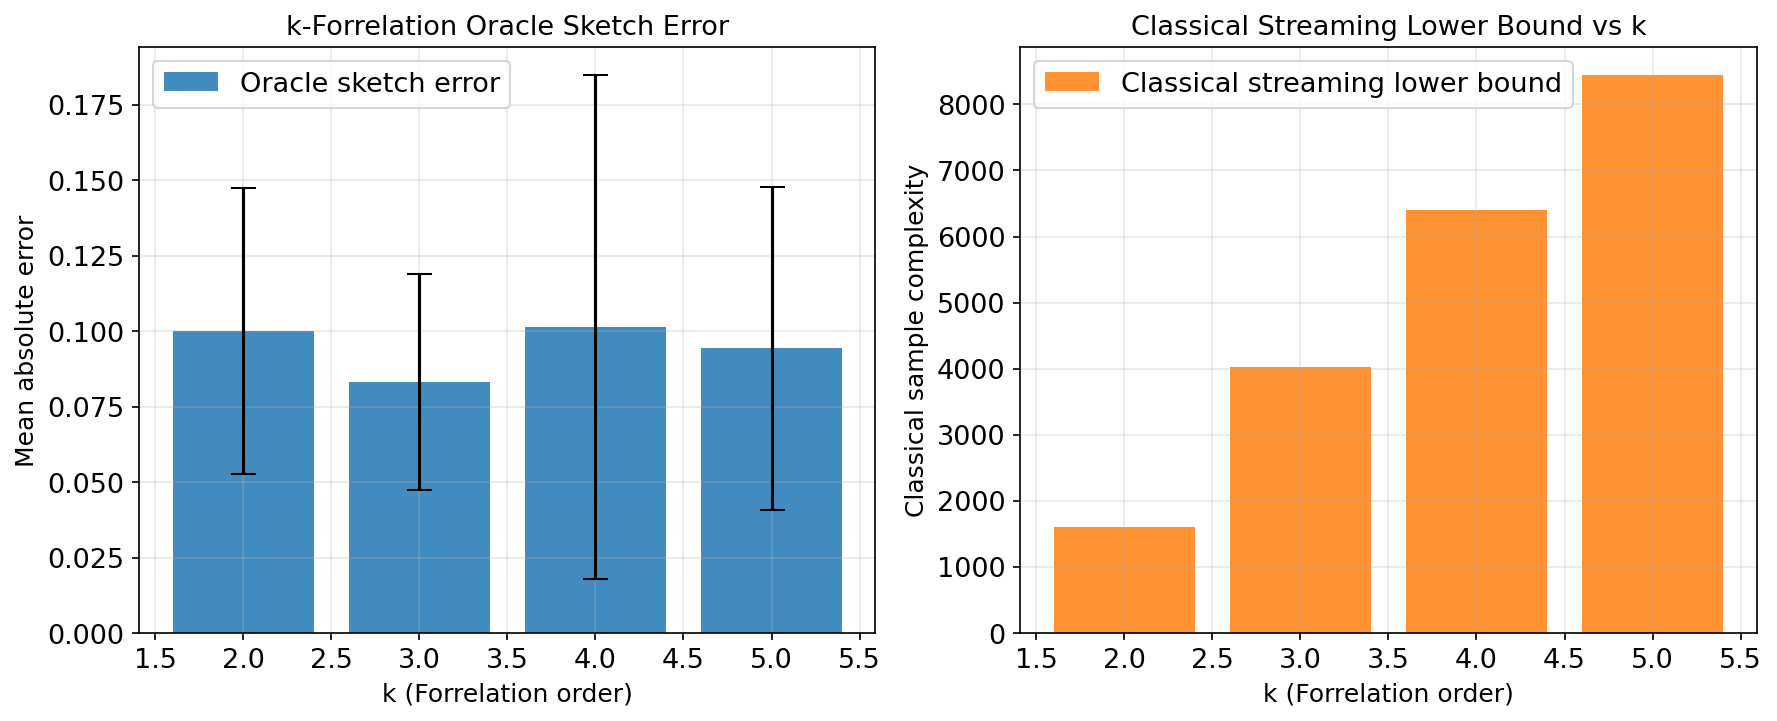

Saved fig4_k_forrelation.pdf / .png


In [7]:
try:
    from qos.data.generation import k_forrelation_data; _ok=True
except ImportError as e: print(f'Skip Fig4: {e}'); _ok=False
if _ok:
    rows=[]
    for k in [2,3,4,5]:
        errs,cb=[],[]
        for t in range(10):
            gen=k_forrelation_data(n=8,k=k,key=jax.random.PRNGKey(t*100+k))
            funcs=gen.sample_functions(jax.random.PRNGKey(t*100+k+1))
            exact=gen.compute_exact_forrelation(funcs)
            truth=((1.0-jnp.sign(funcs[-1]))/2.0).astype(jnp.int32)
            diag,_=q_oracle_sketch_boolean(truth,5000)
            errs.append(abs(float(gen.quantum_query_algorithm(diag))-float(exact)))
            cb.append(gen.classical_streaming_complexity(0.1))
        rows.append({'k':k,'mean_error':float(np.mean(errs)),'std_error':float(np.std(errs)),'classical_bound':int(np.mean(cb))})
    df4=pd.DataFrame(rows)
    df4.to_csv('results/fig4_k_forrelation.csv',index=False)
    print(df4.to_string(index=False))
    # Figure 4: error vs k with classical bound overlay
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.bar(df4['k'], df4['mean_error'], yerr=df4['std_error'], color='#1f77b4', capsize=6, alpha=0.85, label='Oracle sketch error')
    ax1.set_xlabel('k (Forrelation order)'); ax1.set_ylabel('Mean absolute error')
    ax1.set_title('k-Forrelation Oracle Sketch Error'); ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.bar(df4['k'], df4['classical_bound'], color='#ff7f0e', alpha=0.85, label='Classical streaming lower bound')
    ax2.set_xlabel('k (Forrelation order)'); ax2.set_ylabel('Classical sample complexity')
    ax2.set_title('Classical Streaming Lower Bound vs k'); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('results/fig4_k_forrelation.pdf'); plt.savefig('results/fig4_k_forrelation.png'); plt.show()
    print('Saved fig4_k_forrelation.pdf / .png')

## Cell 6 — Figure 5: Kernel vs Linear Shadow

 dim  kernel_acc  kernel_std  linear_acc  linear_std
  16    0.553125    0.111410    0.437500    0.078062
  32    0.568750    0.114394    0.396875    0.087890
  64    0.543750    0.060917    0.487500    0.059948
 128    0.553125    0.111410    0.437500    0.108972


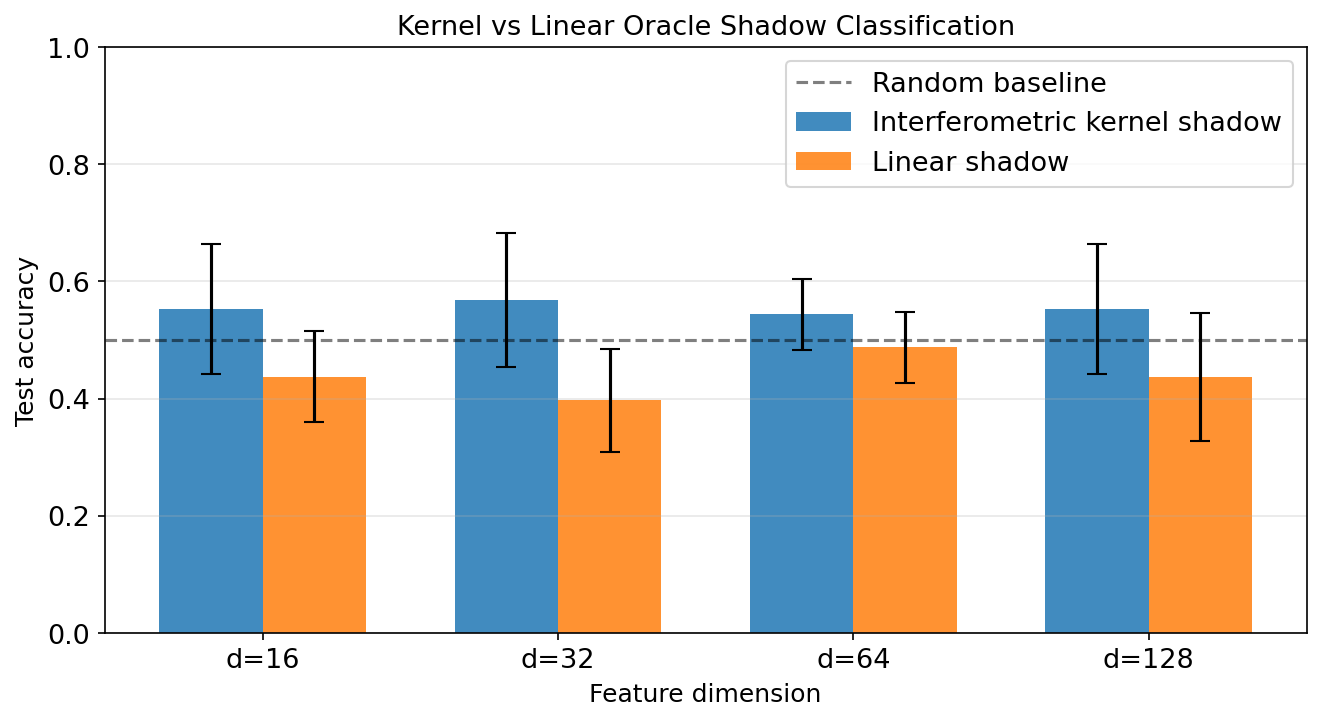

Saved fig5_kernel_vs_linear.pdf / .png


In [8]:
try:
    from qos.core.state_sketch import q_state_sketch_flat, fit_kernel_svm_from_states, q_interferometric_kernel_shadow; _ok=True
except ImportError as e: print(f'Skip Fig5: {e}'); _ok=False
if _ok:
    def _shadow(d,n_tr,n_te,M,key):
        k1,k2,_=jax.random.split(key,3)
        Xtr=jax.random.normal(k1,(n_tr,d)); ytr=jnp.sign(Xtr[:,0]).astype(jnp.int32)
        Xte=jax.random.normal(k2,(n_te,d)); yte=jnp.sign(Xte[:,0]).astype(jnp.int32)
        str_=jnp.stack([q_state_sketch_flat(Xtr[i],M)[0] for i in range(n_tr)])
        ste_=jnp.stack([q_state_sketch_flat(Xte[i],M)[0] for i in range(n_te)])
        alpha=fit_kernel_svm_from_states(str_,ytr)
        kp=jnp.array([q_interferometric_kernel_shadow(str_,ytr,alpha,ste_[i]) for i in range(n_te)])
        lp=ytr[jnp.argmax(jnp.abs(jnp.einsum('id,jd->ij',ste_,str_))**2,axis=1)]
        return float(jnp.mean(kp==yte)), float(jnp.mean(lp==yte))
    rows=[]
    for d in [16,32,64,128]:
        ka_,la_=[],[]
        for t in range(8): ka,la=_shadow(d,20,40,2000,jax.random.PRNGKey(t*7+d)); ka_.append(ka); la_.append(la)
        rows.append({'dim':d,'kernel_acc':np.mean(ka_),'kernel_std':np.std(ka_),'linear_acc':np.mean(la_),'linear_std':np.std(la_)})
    df5=pd.DataFrame(rows)
    df5.to_csv('results/fig5_kernel_vs_linear.csv',index=False)
    print(df5.to_string(index=False))
    # Figure 5: kernel vs linear accuracy across dimensions
    x = np.arange(len(df5))
    width = 0.35
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - width/2, df5['kernel_acc'], width, yerr=df5['kernel_std'],
           color='#1f77b4', capsize=5, alpha=0.85, label='Interferometric kernel shadow')
    ax.bar(x + width/2, df5['linear_acc'], width, yerr=df5['linear_std'],
           color='#ff7f0e', capsize=5, alpha=0.85, label='Linear shadow')
    ax.axhline(0.5, color='k', linestyle='--', alpha=0.5, label='Random baseline')
    ax.set_xticks(x); ax.set_xticklabels([f'd={d}' for d in df5['dim']])
    ax.set_xlabel('Feature dimension'); ax.set_ylabel('Test accuracy')
    ax.set_ylim(0, 1); ax.set_title('Kernel vs Linear Oracle Shadow Classification')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('results/fig5_kernel_vs_linear.pdf'); plt.savefig('results/fig5_kernel_vs_linear.png'); plt.show()
    print('Saved fig5_kernel_vs_linear.pdf / .png')

## Cell 7 — Download all results

In [9]:
results_dir = os.path.join(_repo, 'results')
for fname in sorted(os.listdir(results_dir)):
    print(f'  {fname:45s} {os.path.getsize(os.path.join(results_dir,fname)):>8,} bytes')
'[patched: shutil.make_archive skipped]'
print('✓ Download marena2026_results.zip from the Files panel.')

  fig1_combined.pdf                               27,976 bytes
  fig1_combined.png                              312,897 bytes
  fig1a_N512_K16.csv                                 678 bytes
  fig1a_main.pdf                                  22,853 bytes
  fig1a_main.png                                 158,843 bytes
  fig1b_N1024_K16.csv                                658 bytes
  fig1b_largeN.pdf                                22,559 bytes
  fig1b_largeN.png                               158,682 bytes
  fig2_tightness_sweep.csv                           809 bytes
  fig2_tightness_sweep.pdf                        24,296 bytes
  fig2_tightness_sweep.png                       130,894 bytes
  fig3_nisq_crossover.csv                          2,553 bytes
  fig3_nisq_crossover.pdf                         21,138 bytes
  fig3_nisq_crossover.png                        159,928 bytes
  fig4_k_forrelation.csv                             230 bytes
  fig4_k_forrelation.pdf                          18,21